In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [ ]:
df = pd.read_csv('train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [60]:
df.shape

(1460, 81)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [62]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [63]:
df.isnull().mean()*100

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

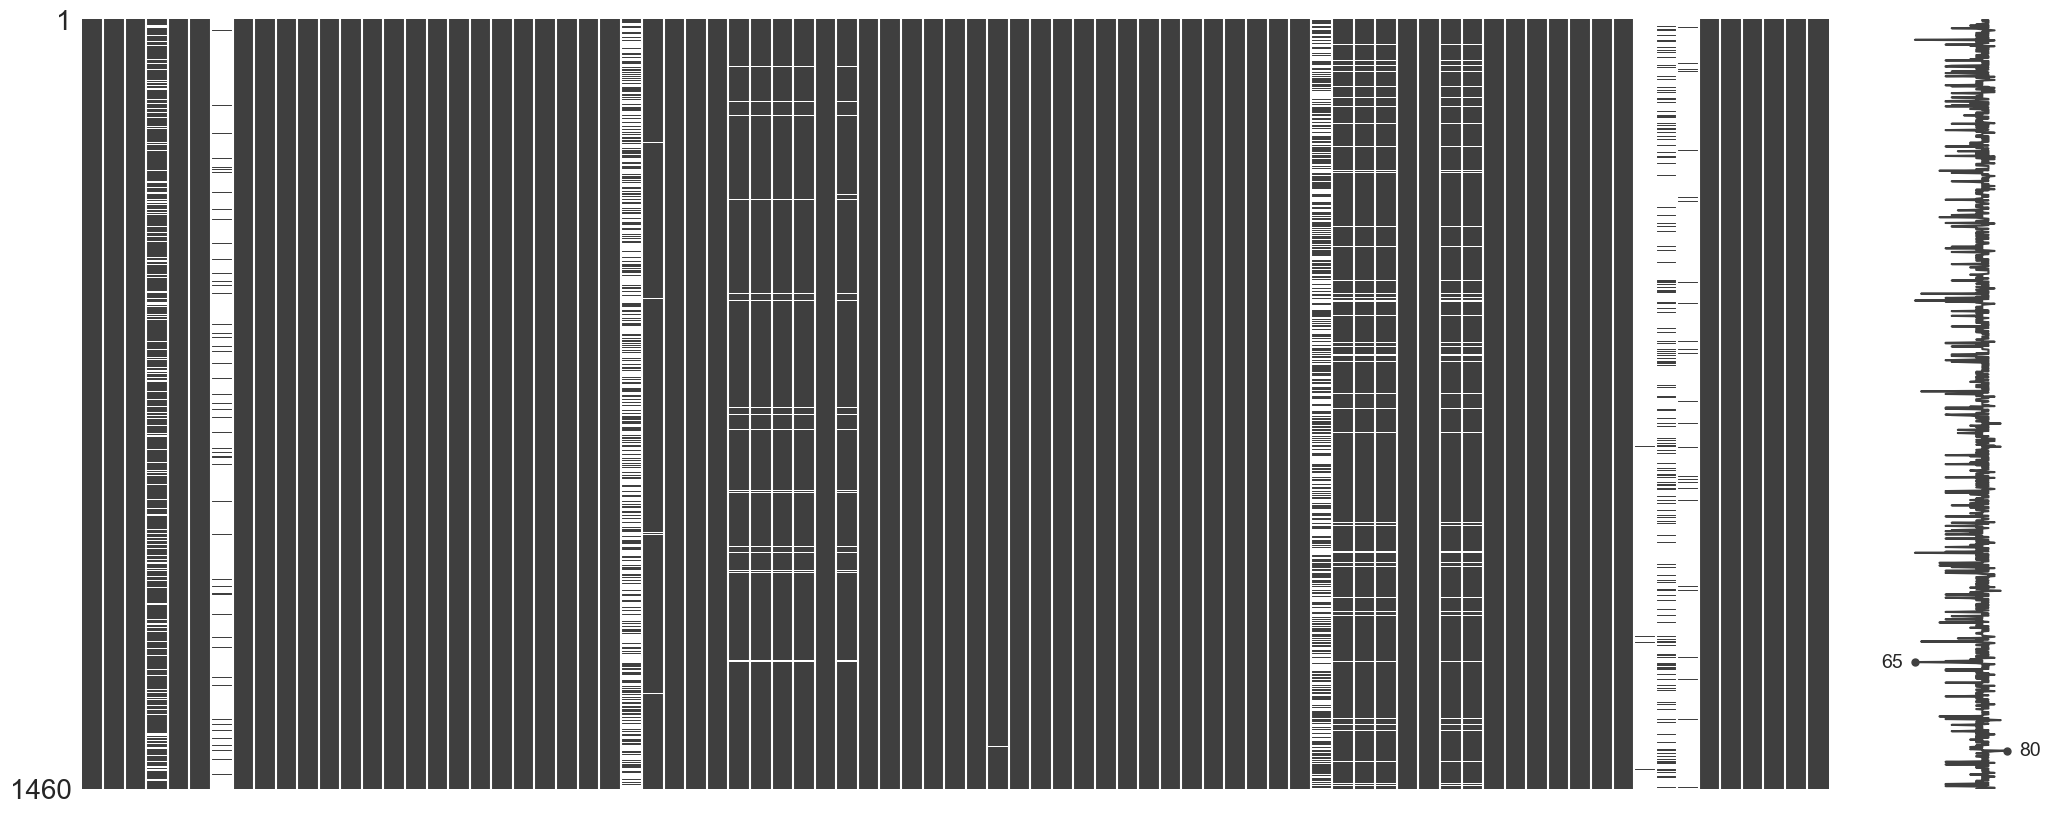

In [64]:
msno.matrix(df)
plt.show()

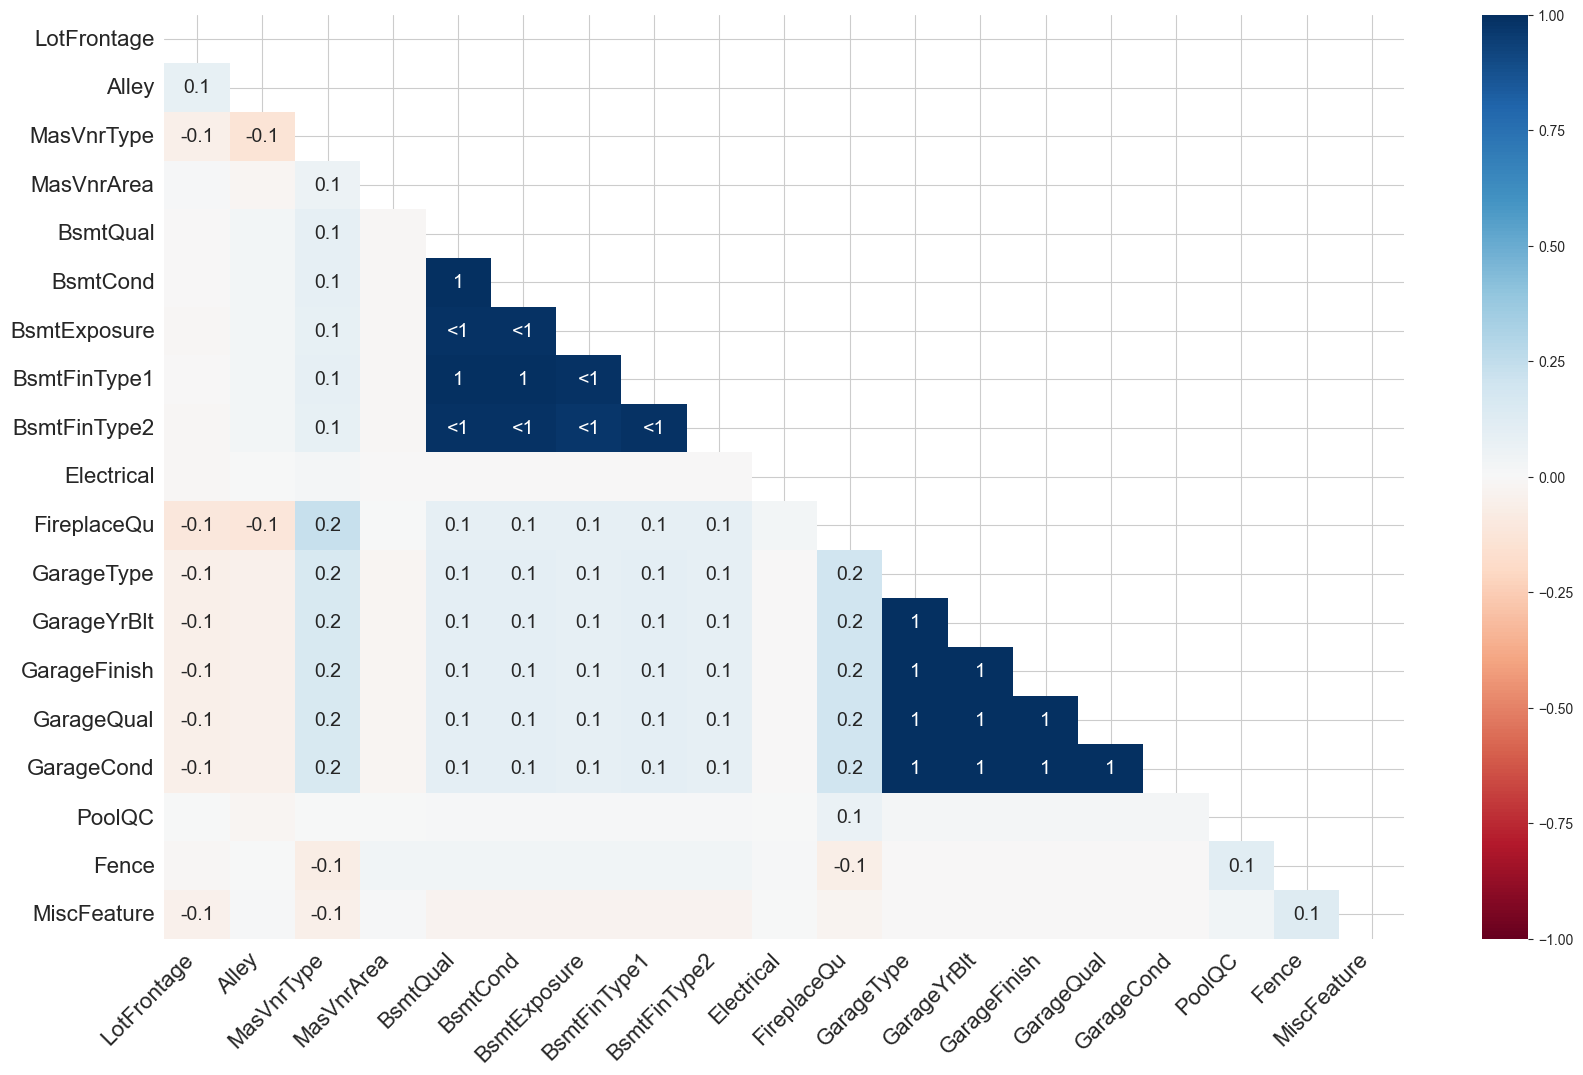

In [65]:
msno.heatmap(df)
plt.show()

In [66]:
kolom_pemeriksaan = df.columns.drop("Id")

duplikat = df.duplicated(subset=kolom_pemeriksaan)

print("Jumlah baris duplikat:", duplikat.sum())

Jumlah baris duplikat: 0


In [67]:
fitur_kategorikal = df.select_dtypes(include=['object', 'category']).columns

fitur_numerik = df.select_dtypes(include=["number"]).columns

print("Fitur kategorikal:", fitur_kategorikal)
print("Fitur numerik:", fitur_numerik)

Fitur kategorikal: Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')
Fitur numerik: Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
 

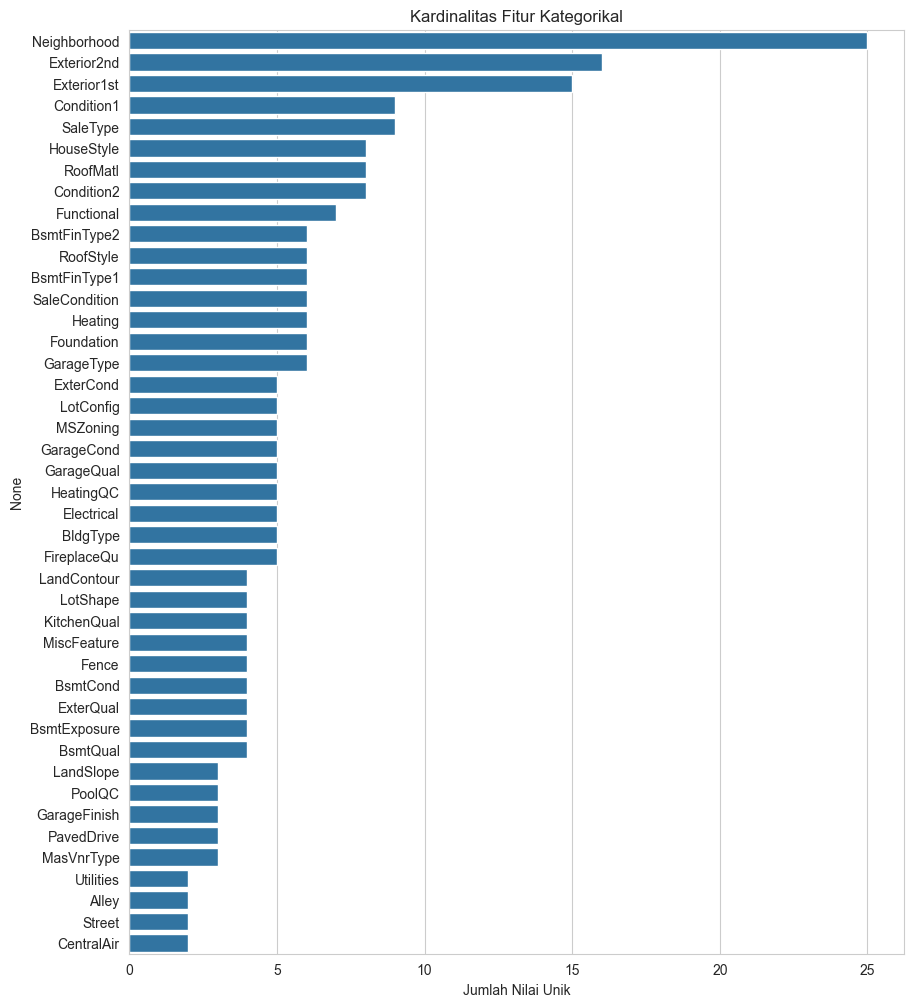

In [68]:
card = pd.DataFrame({
    'Jumlah Unik': df[fitur_kategorikal].nunique(),
    'Contoh Nilai': [df[c].dropna().unique()[:5].tolist() for c in fitur_kategorikal]
}).sort_values('Jumlah Unik', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x=card['Jumlah Unik'], y=card.index)
plt.xlabel('Jumlah Nilai Unik')
plt.title('Kardinalitas Fitur Kategorikal')
plt.show()


In [69]:
cat = df.select_dtypes(include='object').columns.tolist()

rows = []
for c in cat:
    vc = df[c].value_counts(dropna=False)
    pct = df[c].value_counts(normalize=True, dropna=False).iloc[0]*100
    top = 'Missing' if pd.isna(vc.index[0]) else str(vc.index[0])
    rows.append((c, df[c].nunique(dropna=False), top, round(pct,2)))

pd.DataFrame(rows, columns=['fitur','n_kat','top','top_pct']).sort_values('top_pct', ascending=False)


,fitur,n_kat,top,top_pct
5,Utilities,2,AllPub,99.93
1,Street,2,Pave,99.59
38,PoolQC,4,Missing,99.52
10,Condition2,8,Norm,98.97
14,RoofMatl,8,CompShg,98.22
26,Heating,6,GasA,97.81
40,MiscFeature,5,Missing,96.30
7,LandSlope,3,Gtl,94.66
2,Alley,3,Missing,93.77
28,CentralAir,2,Y,93.49


Jumlah fitur numerikal: 37
                count       mean       std      min        25%       50%  \
MiscVal        1460.0      43.49    496.12      0.0       0.00       0.0   
PoolArea       1460.0       2.76     40.18      0.0       0.00       0.0   
LotArea        1460.0   10516.83   9981.26   1300.0    7553.50    9478.5   
3SsnPorch      1460.0       3.41     29.32      0.0       0.00       0.0   
LowQualFinSF   1460.0       5.84     48.62      0.0       0.00       0.0   
KitchenAbvGr   1460.0       1.05      0.22      0.0       1.00       1.0   
BsmtFinSF2     1460.0      46.55    161.32      0.0       0.00       0.0   
ScreenPorch    1460.0      15.06     55.76      0.0       0.00       0.0   
BsmtHalfBath   1460.0       0.06      0.24      0.0       0.00       0.0   
EnclosedPorch  1460.0      21.95     61.12      0.0       0.00       0.0   
MasVnrArea     1452.0     103.69    181.07      0.0       0.00       0.0   
OpenPorchSF    1460.0      46.66     66.26      0.0       0.0

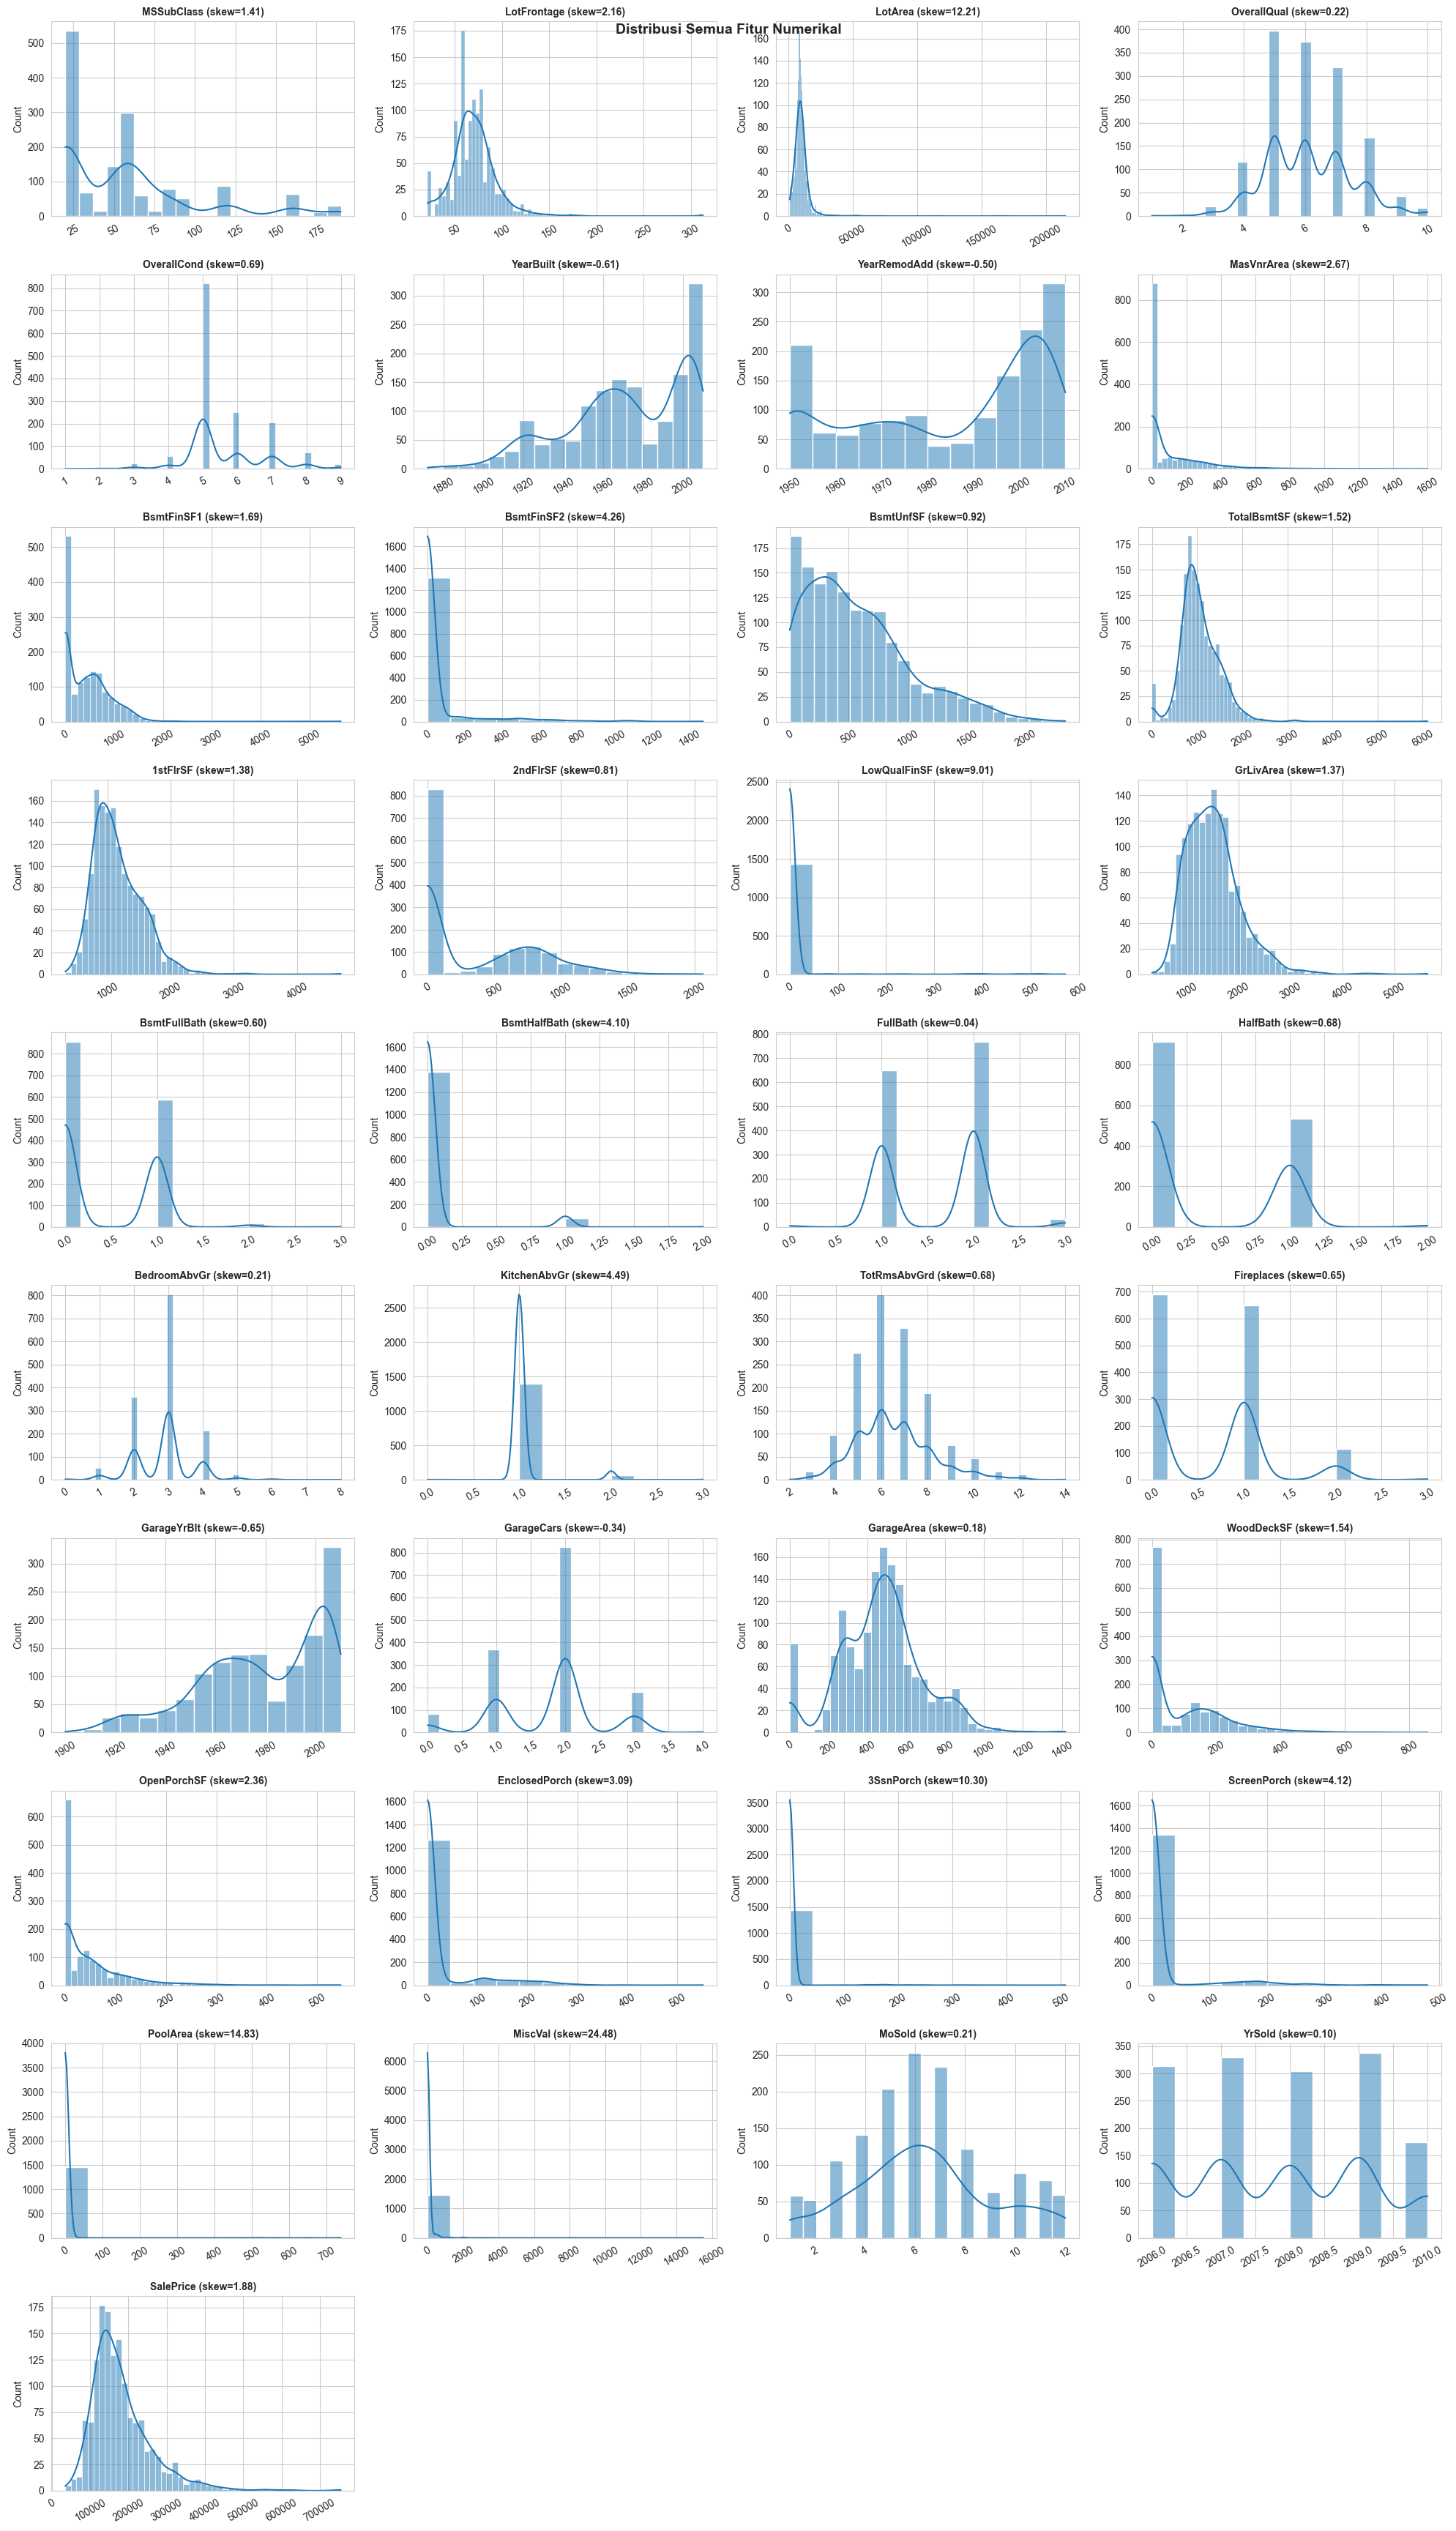

In [70]:
num_cols = df.select_dtypes(include='number').columns.drop('Id')
print(f"Jumlah fitur numerikal: {len(num_cols)}")

# 1. Tabel ringkas + skew (output terminal / cell)
desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
print(desc.round(2).sort_values('skew', ascending=False))

# 2. Distribusi: histogram + KDE semua fitur
sns.set_style("whitegrid")
ncols = 4
nrows = (len(num_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} (skew={df[col].skew():.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)

for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.suptitle("Distribusi Semua Fitur Numerikal", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()




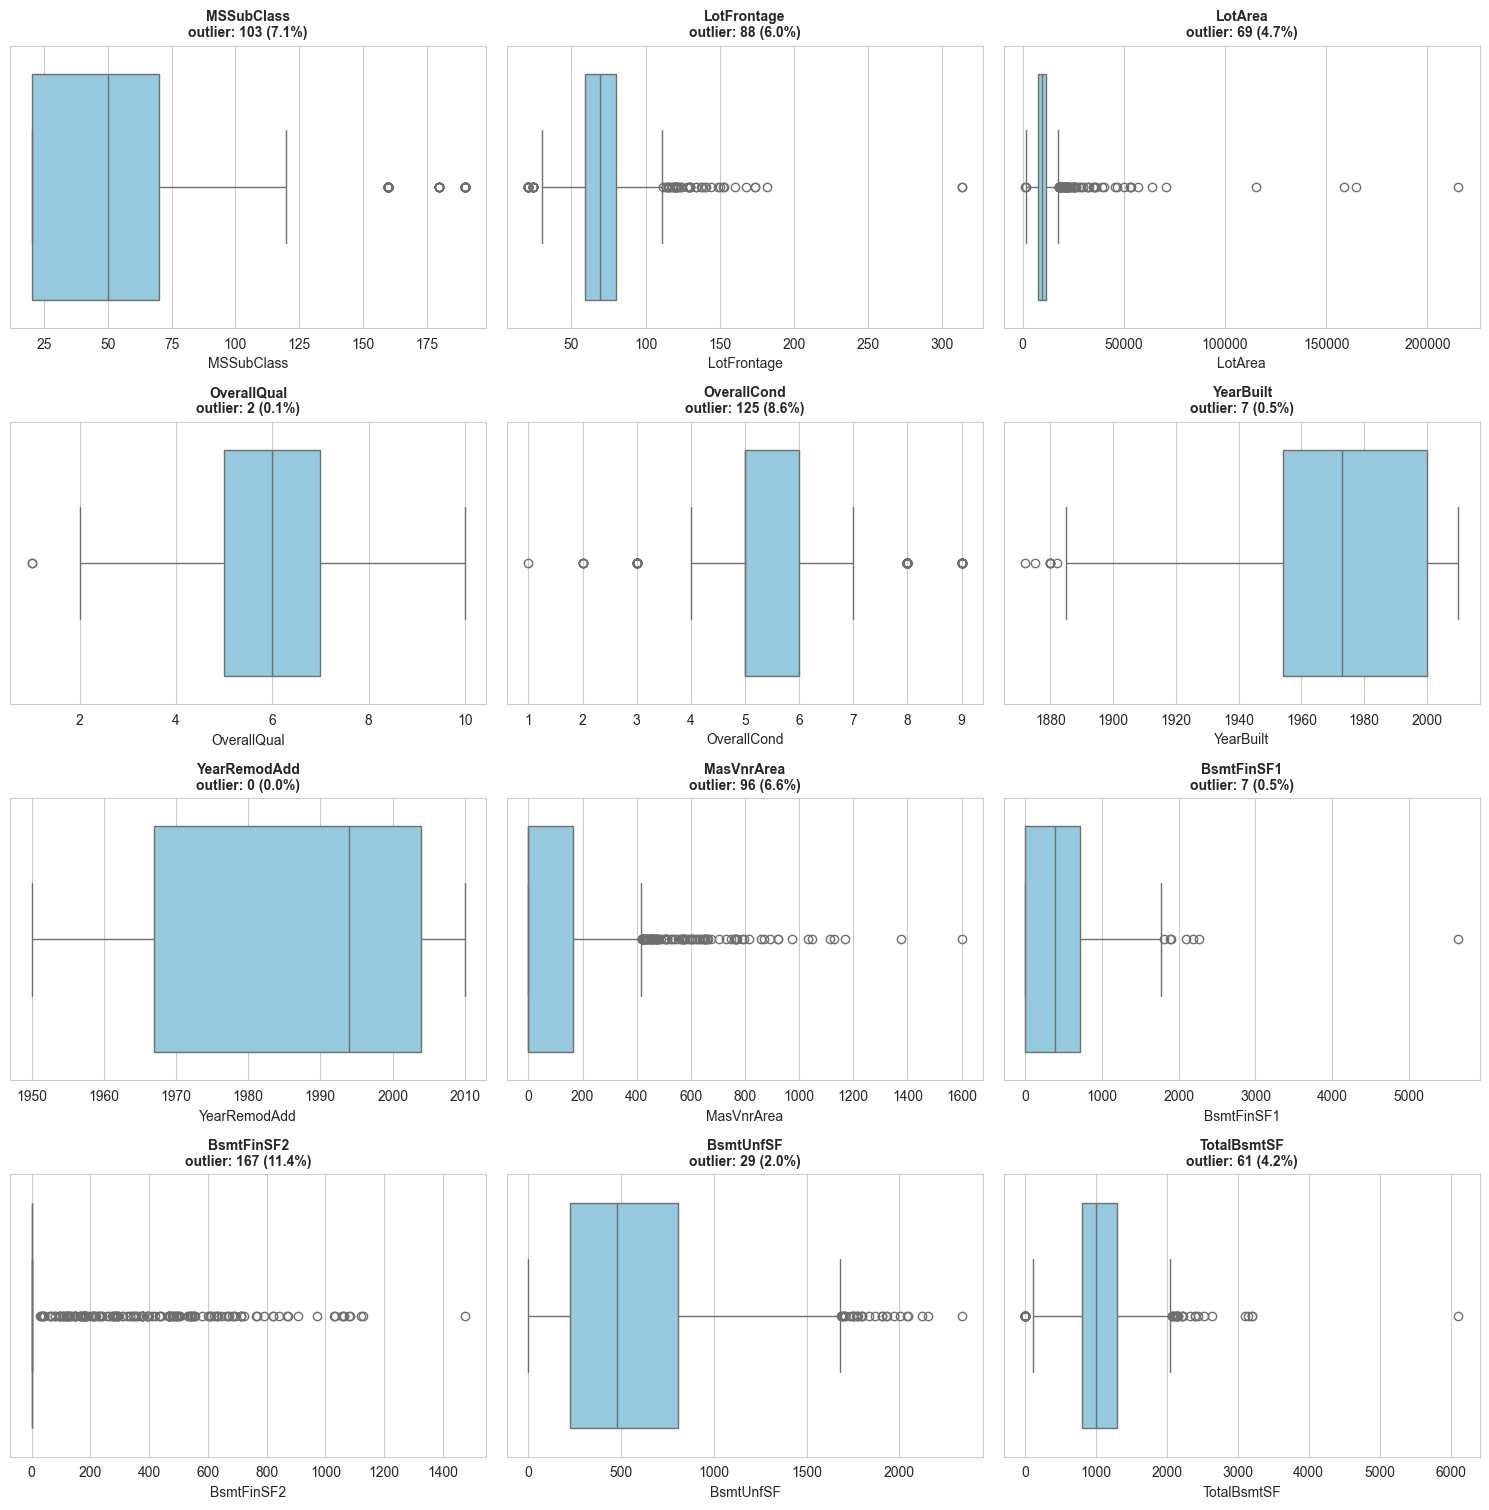

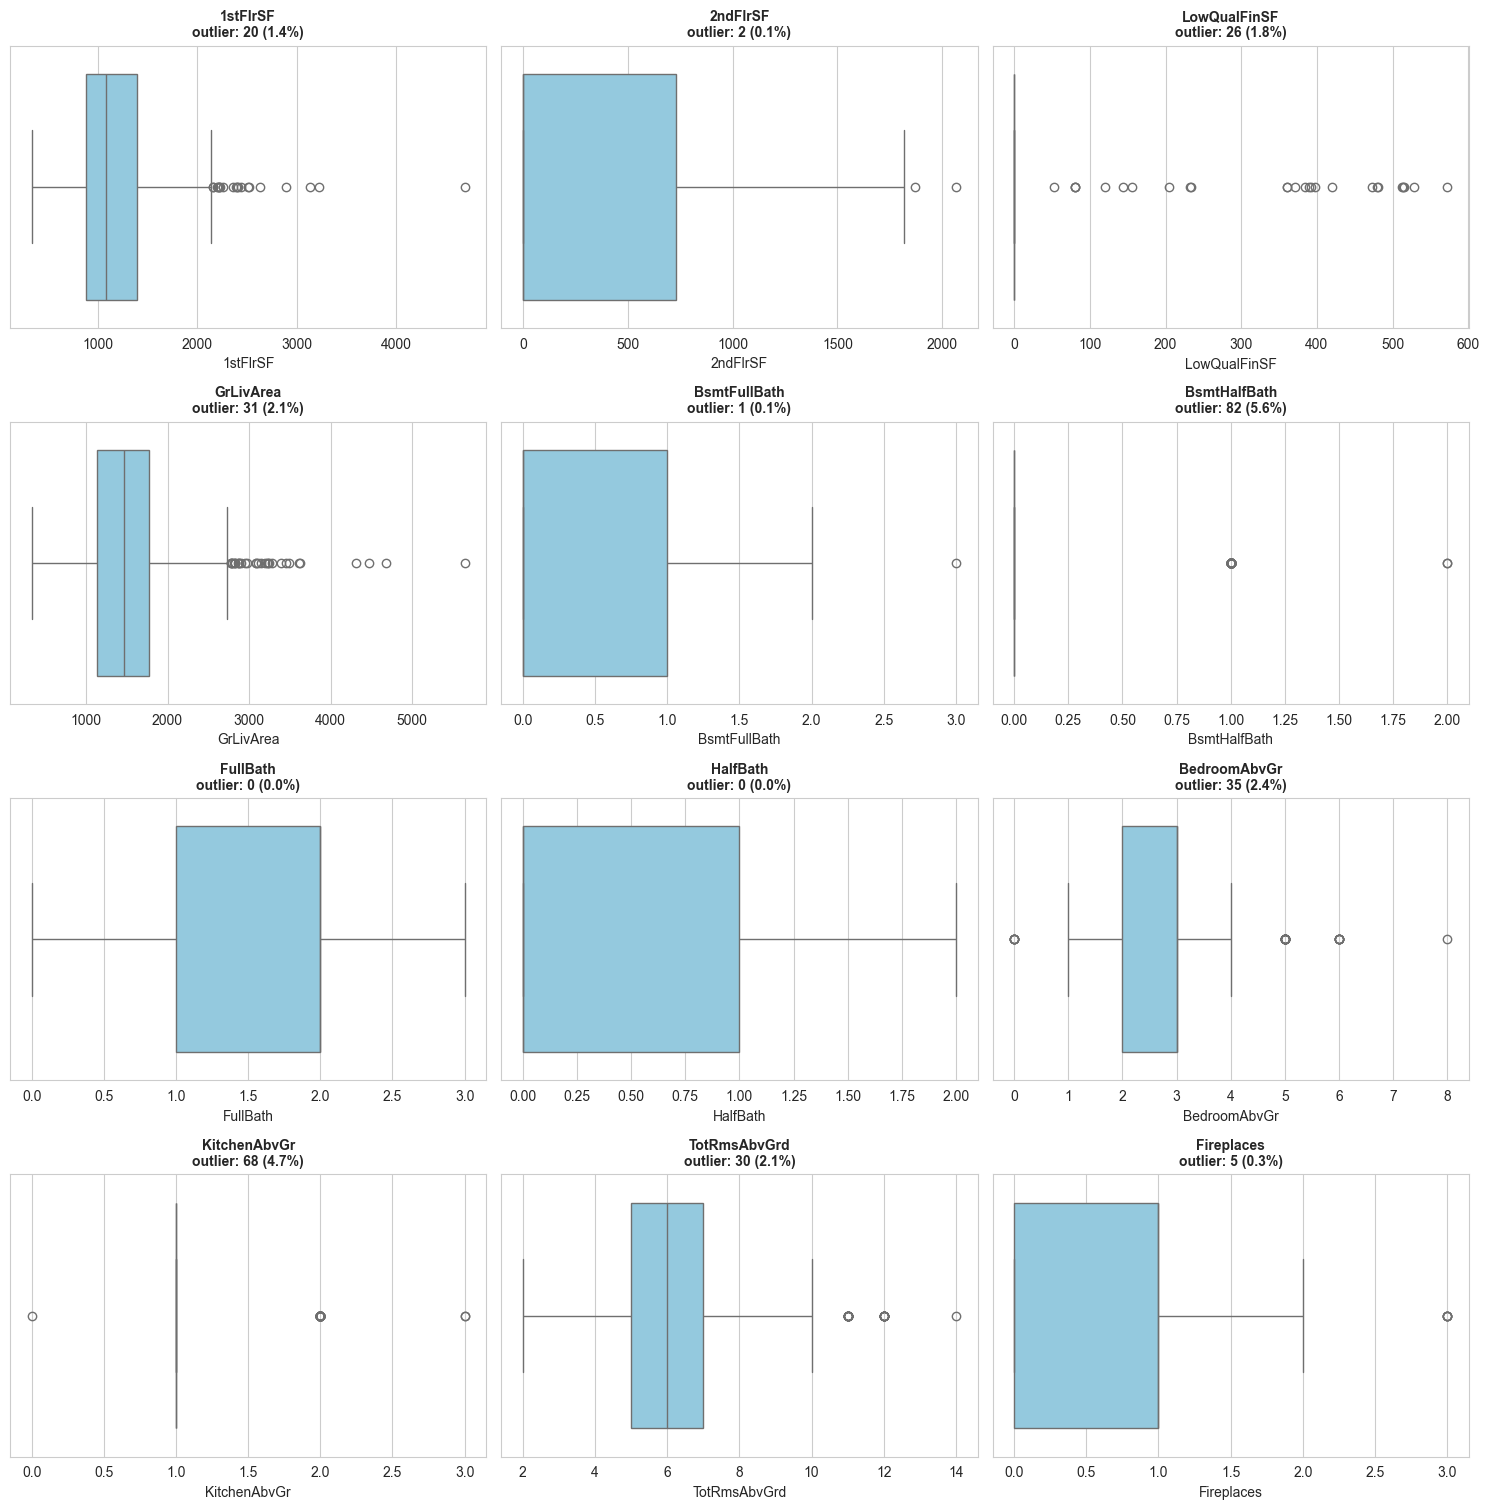

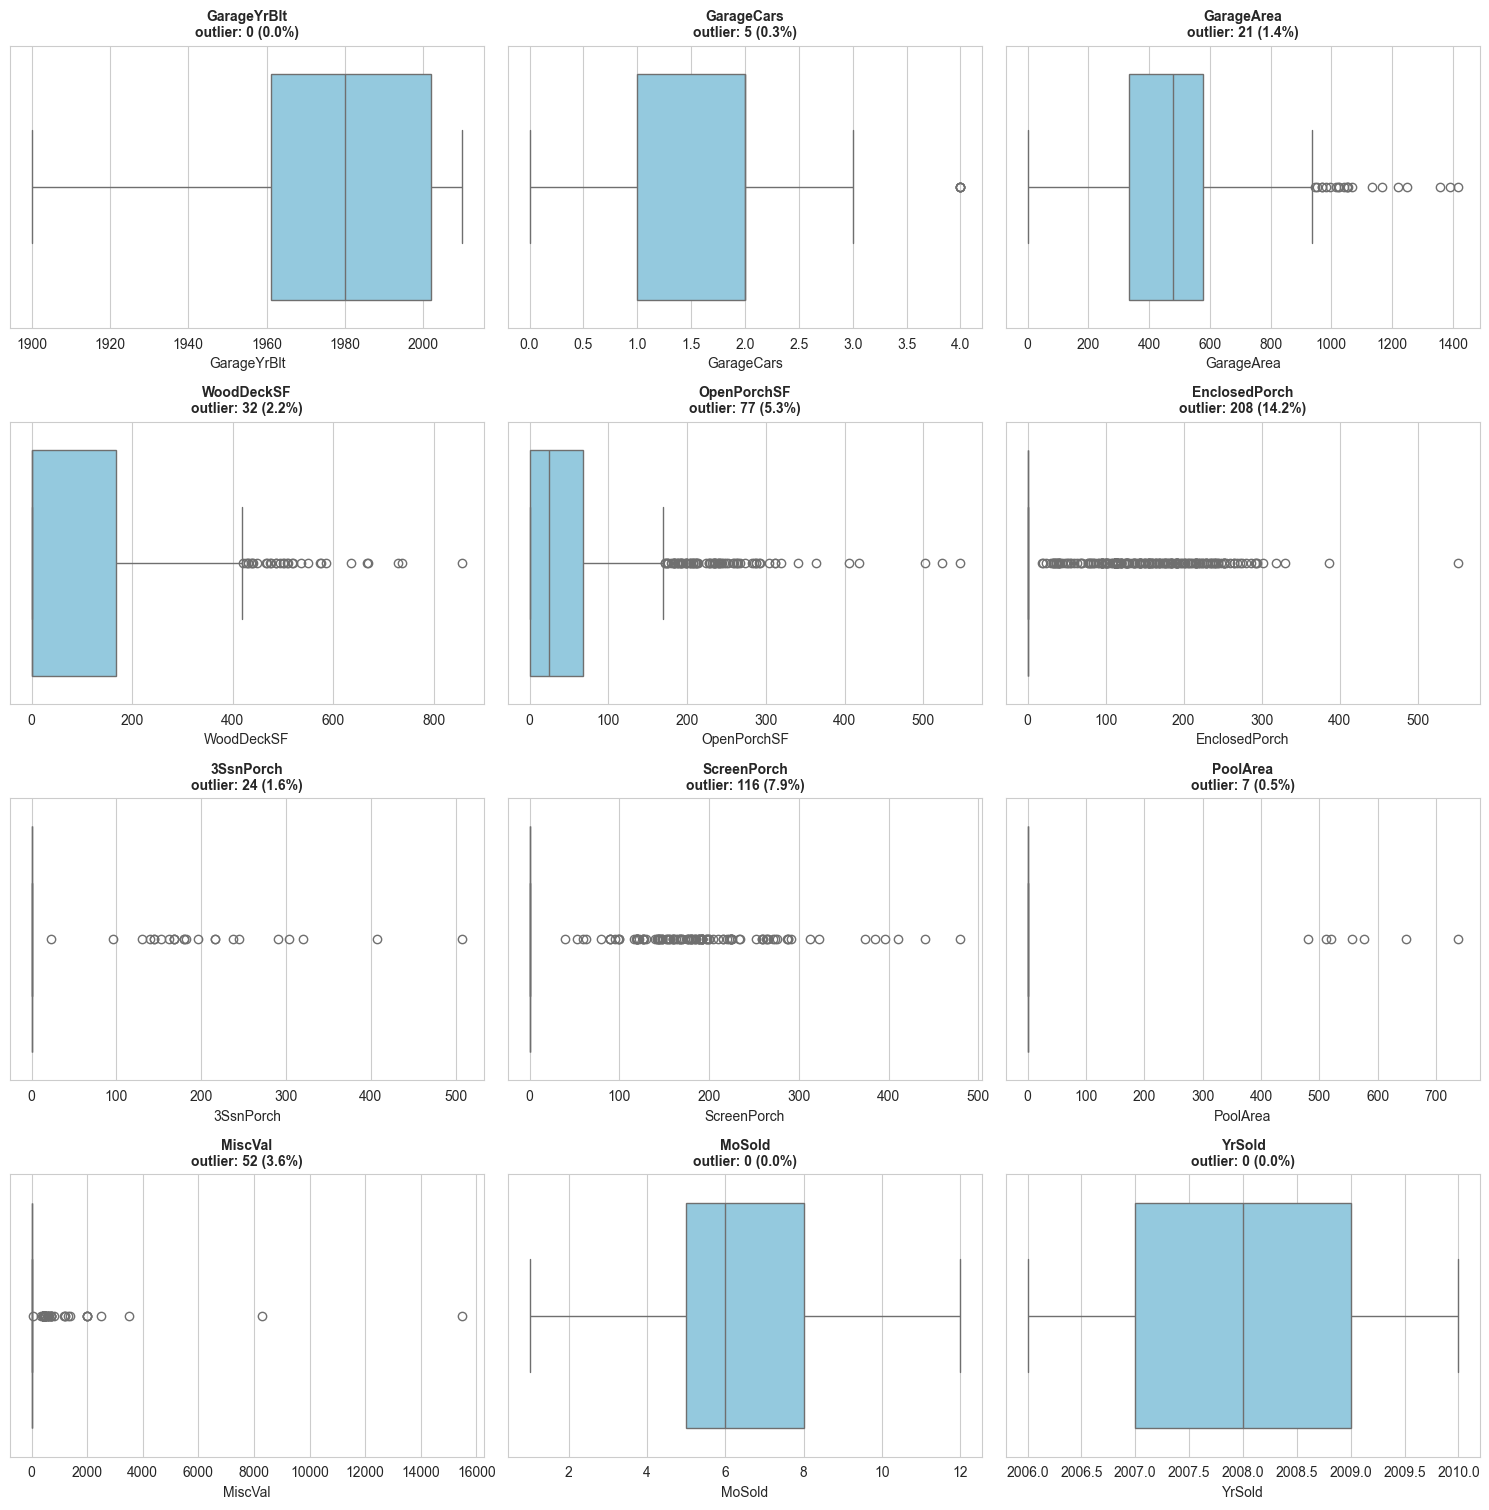

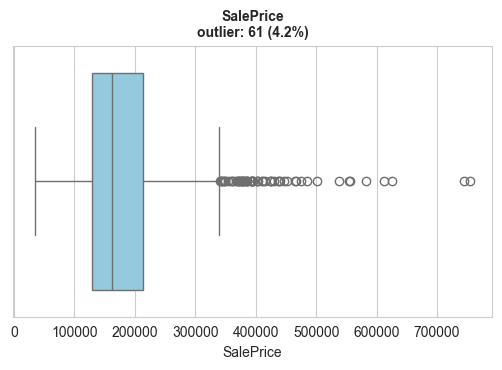

In [71]:
sns.set_style("whitegrid")
ncols, figsize_w = 3, 15
for i in range(0, len(num_cols), 12):
    chunk = num_cols[i:i+12]
    nrows = (len(chunk) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_w, 3.8*nrows))
    axes = axes.flatten()
    for ax, col in zip(axes, chunk):
        sns.boxplot(x=df[col], ax=ax, color="skyblue")
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        n_out = int(((df[col] < q1-1.5*(q3-q1)) | (df[col] > q3+1.5*(q3-q1))).sum())
        ax.set_title(f"{col}\noutlier: {n_out} ({n_out/len(df)*100:.1f}%)", fontweight="bold", fontsize=10)
    for ax in axes[len(chunk):]:
        fig.delaxes(ax)
    plt.tight_layout()
    plt.show()

SalePrice        1.000
OverallQual      0.791
GrLivArea        0.709
GarageCars       0.640
GarageArea       0.623
TotalBsmtSF      0.614
1stFlrSF         0.606
FullBath         0.561
TotRmsAbvGrd     0.534
YearBuilt        0.523
YearRemodAdd     0.507
GarageYrBlt      0.486
MasVnrArea       0.477
Fireplaces       0.467
BsmtFinSF1       0.386
LotFrontage      0.352
WoodDeckSF       0.324
2ndFlrSF         0.319
OpenPorchSF      0.316
HalfBath         0.284
LotArea          0.264
BsmtFullBath     0.227
BsmtUnfSF        0.214
BedroomAbvGr     0.168
ScreenPorch      0.111
PoolArea         0.092
MoSold           0.046
3SsnPorch        0.045
BsmtFinSF2      -0.011
BsmtHalfBath    -0.017
MiscVal         -0.021
LowQualFinSF    -0.026
YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136
Name: SalePrice, dtype: float64


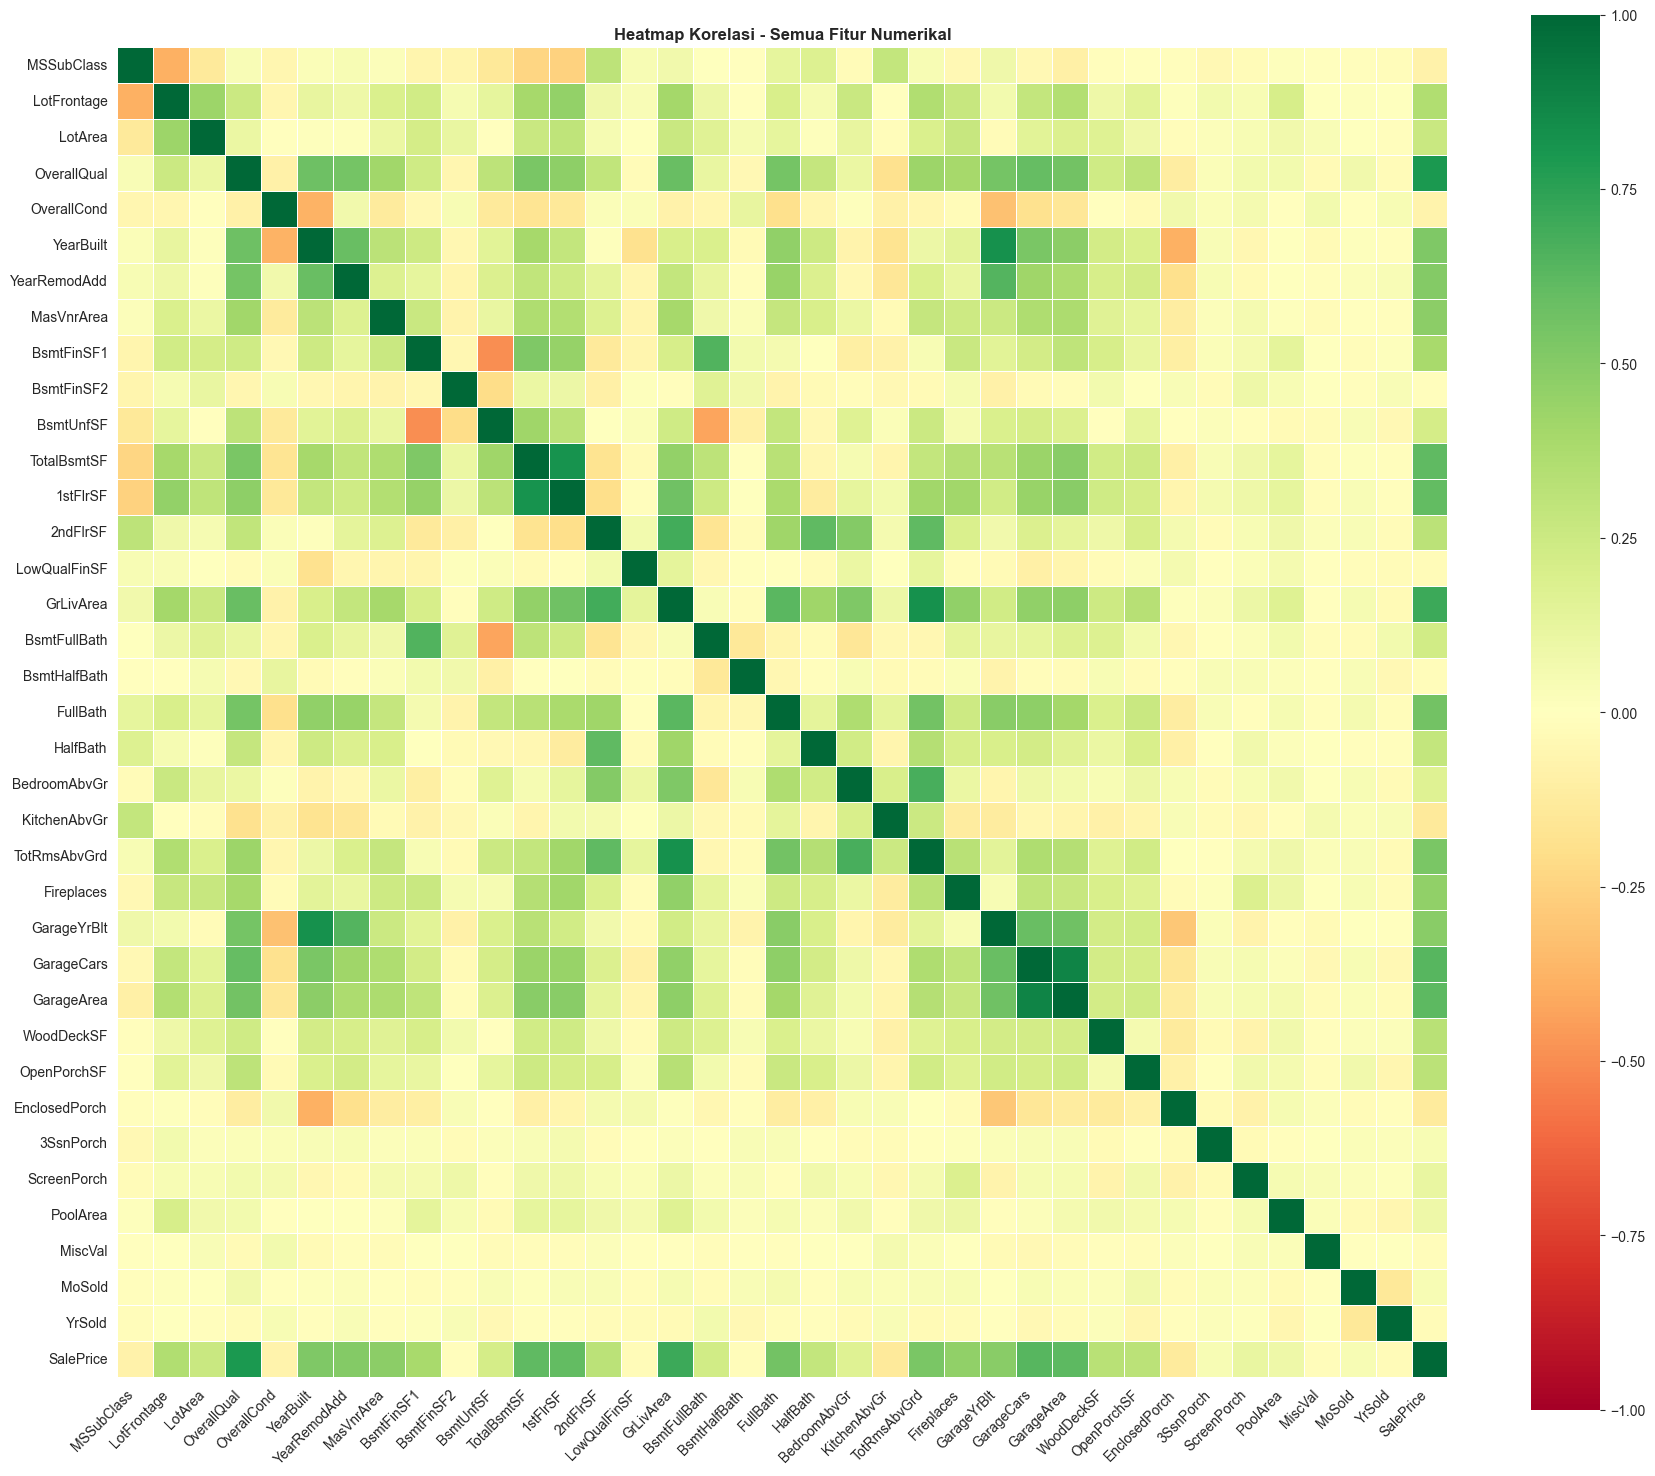

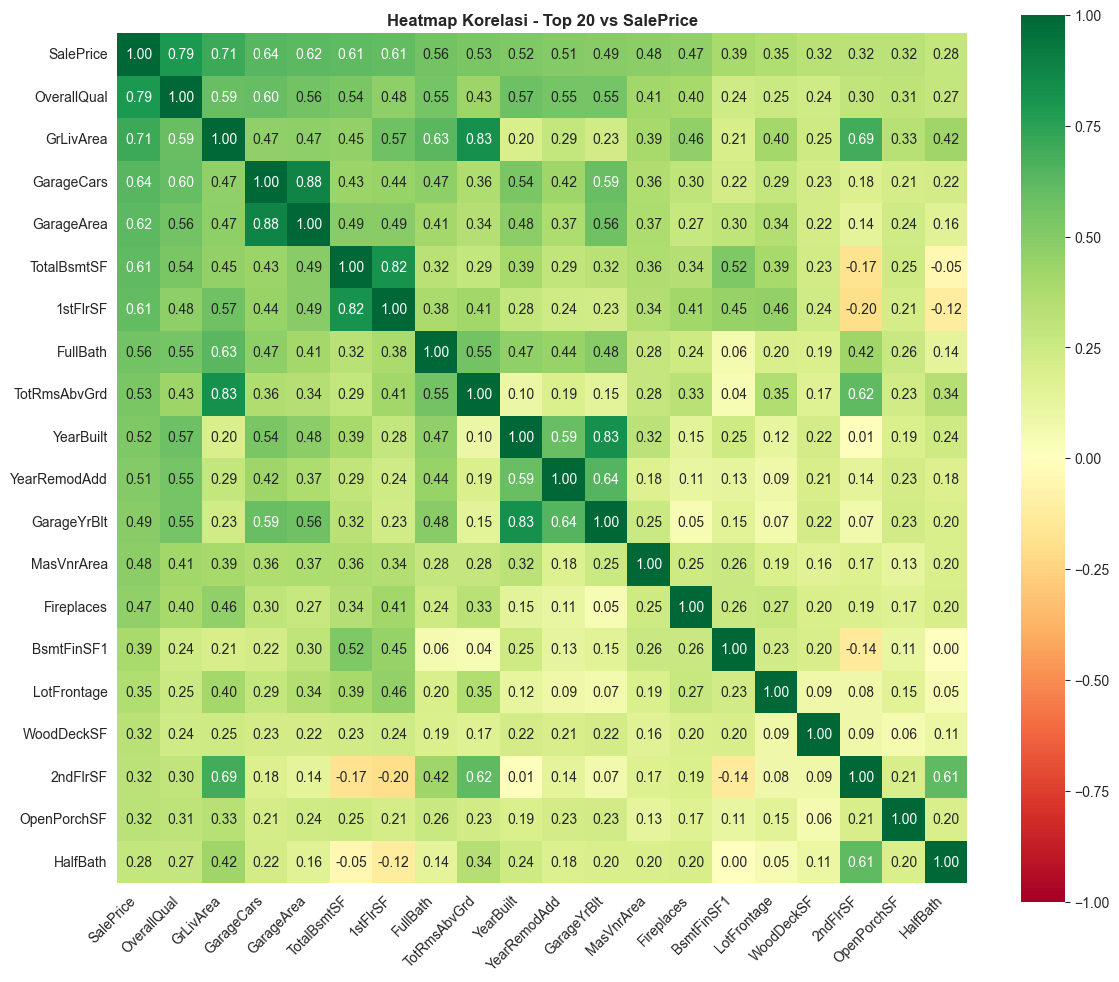

In [72]:
num = df.select_dtypes(include='number').columns.drop('Id')
corr = df[num].corr(numeric_only=True)

# 1. Lihat angka di terminal / cell
print(corr['SalePrice'].sort_values(ascending=False).round(3))

# 2. Heatmap full
plt.figure(figsize=(18, 15))
sns.heatmap(corr, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi - Semua Fitur Numerikal', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Heatmap Top 20 vs SalePrice (lebih kebaca + ada angkanya)
top20 = corr['SalePrice'].sort_values(ascending=False).head(20).index
plt.figure(figsize=(12, 10))
sns.heatmap(df[top20].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, square=True)
plt.title('Heatmap Korelasi - Top 20 vs SalePrice', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [73]:
# --- 1a. NaN = "tidak punya fitur ini" -> isi dengan "None" ---
none_fill_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_fill_cols:
    df[col] = df[col].fillna('None')
 
# --- 1b. Numerik terkait "tidak punya fitur ini" -> isi 0 ---
zero_fill_cols = ['GarageYrBlt', 'MasVnrArea']
for col in zero_fill_cols:
    df[col] = df[col].fillna(0)
 
# --- 1c. Missing beneran -> imputasi statistik ---
# LotFrontage: median per Neighborhood (lebih akurat daripada median global)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'] \
    .transform(lambda x: x.fillna(x.median()))
# fallback kalau masih ada NaN (neighborhood yang semua barisnya NaN)
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
 
# Electrical: cuma 1 baris hilang -> isi modus
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
 
print(f"Sisa missing value setelah tahap 1: {df.isnull().sum().sum()}")
 
# =========================================================
# 2. BINARY FLAG dari kolom yang NaN-nya dominan (>75%)
#    Dibuat SEBELUM kolom aslinya diproses lebih lanjut,
#    supaya info "punya/tidak" gak hilang meski kolom
#    aslinya nanti disederhanakan atau di-drop.
# =========================================================
flag_map = {
    'PoolQC': 'HasPool',
    'MiscFeature': 'HasMisc',
    'Alley': 'HasAlley',
    'Fence': 'HasFence',
    'FireplaceQu': 'HasFireplace',
}
for src_col, flag_col in flag_map.items():
    df[flag_col] = (df[src_col] != 'None').astype(int)
 
print(f"Shape setelah tambah binary flags: {df.shape}")
 
# =========================================================
# 3. DROP kolom near zero-variance (imbalance ekstrem, non-informatif)
# =========================================================
drop_cols = ['Utilities', 'Street']
df = df.drop(columns=drop_cols)
print(f"Drop kolom: {drop_cols}")
 
# =========================================================
# 4. RARE CATEGORY GROUPING
#    Kategori dengan proporsi < threshold digabung jadi "Other"
#    supaya estimasi per kategori lebih stabil (bukan buat
#    menghilangkan imbalance, tapi menstabilkan sampel kecil).
# =========================================================
def group_rare_categories(series, threshold=0.02):
    freq = series.value_counts(normalize=True, dropna=False)
    rare_labels = freq[freq < threshold].index
    return series.apply(lambda x: 'Other' if x in rare_labels else x)
 
rare_group_cols = [
    'RoofMatl', 'Heating', 'Condition2', 'Condition1',
    'Exterior1st', 'Exterior2nd', 'Functional', 'SaleType',
    'MiscFeature', 'HouseStyle', 'RoofStyle', 'Foundation'
]
cat_cols_existing = df.select_dtypes(include='object').columns.tolist()
 
for col in rare_group_cols:
    if col in cat_cols_existing:
        before = df[col].nunique()
        df[col] = group_rare_categories(df[col], threshold=0.02)
        after = df[col].nunique()
        if before != after:
            print(f"  {col}: {before} -> {after} kategori")
 
# =========================================================
# 5. RINGKASAN AKHIR
# =========================================================
print("\n=== RINGKASAN ===")
print(f"Shape akhir: {df.shape}")
print(f"Total missing value: {df.isnull().sum().sum()}")
print(f"Jumlah fitur kategorikal: {len(df.select_dtypes(include='object').columns)}")
print(f"Jumlah fitur numerik: {len(df.select_dtypes(include=np.number).columns)}")
 


Sisa missing value setelah tahap 1: 0
Shape setelah tambah binary flags: (1460, 86)
Drop kolom: ['Utilities', 'Street']
  RoofMatl: 8 -> 2 kategori
  Heating: 6 -> 2 kategori
  Condition2: 8 -> 2 kategori
  Condition1: 9 -> 4 kategori
  Exterior1st: 15 -> 8 kategori
  Exterior2nd: 16 -> 8 kategori
  Functional: 7 -> 4 kategori
  SaleType: 9 -> 4 kategori
  MiscFeature: 5 -> 3 kategori
  HouseStyle: 8 -> 6 kategori
  RoofStyle: 6 -> 3 kategori
  Foundation: 6 -> 4 kategori

=== RINGKASAN ===
Shape akhir: (1460, 84)
Total missing value: 0
Jumlah fitur kategorikal: 41
Jumlah fitur numerik: 43


In [74]:
# --- 5a. Drop domain-outlier ---
outlier_condition = (df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)
n_outlier = outlier_condition.sum()
df = df[~outlier_condition].reset_index(drop=True)
print(f"\nDrop {n_outlier} baris outlier domain (GrLivArea besar, SalePrice rendah)")
 
# --- 5b. Log-transform target ---
df['SalePrice'] = np.log1p(df['SalePrice'])
print("Log-transform SalePrice -> SalePrice (log1p)")
 
# --- 5b (lanjutan). Log-transform fitur numerik yang skewed ---
# Exclude: Id, target, kolom binary/flag (0/1), dan GarageYrBlt
# (kolom tahun -> log-transform gak relevan buat variabel tahun)
exclude_cols = ['Id', 'SalePrice', 'GarageYrBlt'] + list(flag_map.values())
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols and df[c].nunique() > 2]
 
skewness = df[num_cols].skew()
skewed_cols = skewness[skewness.abs() > 0.75].index.tolist()
 
for col in skewed_cols:
    df[col] = np.log1p(df[col])
 
print(f"Log-transform {len(skewed_cols)} fitur numerik skewed (|skew| > 0.75):")
print(f"  {skewed_cols}")


Drop 2 baris outlier domain (GrLivArea besar, SalePrice rendah)
Log-transform SalePrice -> SalePrice (log1p)
Log-transform 20 fitur numerik skewed (|skew| > 0.75):
  ['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


In [75]:
# =========================================================
# 6. ENCODING FITUR KATEGORIKAL
#    a) Ordinal encoding untuk kolom yang levelnya punya urutan
#       jelas (kualitas: Po<Fa<TA<Gd<Ex, dst) -> mempertahankan
#       info urutan, gak perlu one-hot yang nambah dimensi.
#    b) One-hot encoding untuk kolom nominal (gak ada urutan,
#       misal Neighborhood, MSZoning).
# =========================================================
 
# --- 6a. Ordinal encoding ---
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_maps = {
    'ExterQual':    qual_map,
    'ExterCond':    qual_map,
    'BsmtQual':     qual_map,
    'BsmtCond':     qual_map,
    'HeatingQC':    qual_map,
    'KitchenQual':  qual_map,
    'FireplaceQu':  qual_map,
    'GarageQual':   qual_map,
    'GarageCond':   qual_map,
    'PoolQC':       qual_map,
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'LotShape':     {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3},
    'LandSlope':    {'Sev': 0, 'Mod': 1, 'Gtl': 2},
    'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},
    'CentralAir':   {'N': 0, 'Y': 1},
    'Functional':   {'Other': 0, 'Min2': 1, 'Min1': 2, 'Typ': 3},
}
for col, mapping in ordinal_maps.items():
    df[col] = df[col].fillna('None').map(mapping)
 
print(f"\nOrdinal encoding diterapkan ke {len(ordinal_maps)} kolom")
 
# --- 6b. One-hot encoding untuk sisa kolom nominal ---
nominal_cols = df.select_dtypes(include='object').columns.tolist()
print(f"One-hot encoding diterapkan ke {len(nominal_cols)} kolom nominal:")
print(f"  {nominal_cols}")
 
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
 



Ordinal encoding diterapkan ke 19 kolom
One-hot encoding diterapkan ke 22 kolom nominal:
  ['MSZoning', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [78]:
# =========================================================
# 7. STANDARDISASI FITUR NUMERIK
#    StandardScaler (mean=0, std=1). Dipilih dibanding
#    normalisasi Min-Max karena:
#    - Sudah banyak fitur di-log-transform (bukan bounded/uniform)
#    - Cocok untuk model linear/regularized (Ridge/Lasso) yang
#      sensitif terhadap skala antar fitur
#    - Lebih tahan terhadap outlier sisa dibanding Min-Max
#      (Min-Max sangat terpengaruh oleh nilai min/max ekstrem)
#    Fit di SELURUH train.csv (test set asli sudah ada terpisah,
#    jadi gak perlu displit lagi di sini). Scaler yang sudah
#    di-fit disimpan (pickle) supaya nanti tinggal di-transform()
#    saja ke test set asli -- BUKAN di-fit ulang di sana.
# =========================================================
from sklearn.preprocessing import StandardScaler
 
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']
 
numeric_cols_final = X.select_dtypes(include=np.number).columns.tolist()
# exclude kolom binary (flag & hasil one-hot) dari scaling -> gak perlu di-scale
binary_like = [c for c in numeric_cols_final if X[c].nunique() <= 2]
cols_to_scale = [c for c in numeric_cols_final if c not in binary_like]
 
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
 
print(f"\nStandardScaler di-fit ke seluruh train.csv, {len(cols_to_scale)} fitur numerik kontinu")
print(f"(kolom binary/flag/one-hot, {len(binary_like)} kolom, tidak di-scale)")


StandardScaler di-fit ke seluruh train.csv, 54 fitur numerik kontinu
(kolom binary/flag/one-hot, 6 kolom, tidak di-scale)


In [79]:
# =========================================================
# 8. REDUKSI DIMENSI
# =========================================================
 
# --- 8a. Analisis korelasi -> buang fitur yang sangat berkorelasi ---
# Threshold 0.85: pasangan fitur dengan korelasi > 0.85 dianggap
# redundan (memberi informasi yang nyaris sama ke model).
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
 
CORR_THRESHOLD = 0.85
high_corr_pairs = [
    (col, row, upper_triangle.loc[row, col])
    for col in upper_triangle.columns
    for row in upper_triangle.index
    if pd.notna(upper_triangle.loc[row, col]) and upper_triangle.loc[row, col] > CORR_THRESHOLD
]
 
# Dari tiap pasangan, buang salah satu (kolom kedua) -> kumpulkan unique
cols_to_drop_corr = sorted(set(pair[0] for pair in high_corr_pairs))
 
print(f"\nPasangan fitur dengan korelasi > {CORR_THRESHOLD}:")
for c1, c2, val in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f"  {c2} <-> {c1} : {val:.2f}")
 
print(f"\nDrop {len(cols_to_drop_corr)} fitur redundan (korelasi tinggi): {cols_to_drop_corr}")
 
X = X.drop(columns=cols_to_drop_corr)
print(f"Shape setelah drop fitur berkorelasi tinggi: {X.shape}")
 
# --- 8b. PCA ---
# Diterapkan SETELAH drop fitur redundan, karena PCA sendiri
# sebenarnya sudah menangani multikolinearitas -- tapi drop manual
# duluan bikin komponen PCA lebih mudah diinterpretasi dan
# mengurangi noise dari fitur yang murni duplikat informasi.
# n_components dipilih otomatis: jumlah komponen minimum yang
# mempertahankan >=95% variance data asli.
# Sama seperti scaler: pca di-fit di seluruh train.csv, lalu
# disimpan supaya bisa di-transform() saja ke test set asli.
from sklearn.decomposition import PCA
 
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)
 
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca = pd.DataFrame(X_pca, columns=pca_cols, index=X.index)
 
print(f"\nPCA: {X.shape[1]} fitur -> {X_pca.shape[1]} komponen "
      f"(mempertahankan {pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
print("Explained variance per komponen (5 pertama):")
for i, ratio in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {ratio*100:.1f}%")


Pasangan fitur dengan korelasi > 0.85:
  HasAlley <-> Alley_None : 1.00
  HasFence <-> Fence_None : 1.00
  PoolArea <-> HasPool : 1.00
  GarageYrBlt <-> GarageType_None : 1.00
  SaleType_New <-> SaleCondition_Partial : 0.99
  Exterior1st_VinylSd <-> Exterior2nd_VinylSd : 0.98
  Exterior1st_MetalSd <-> Exterior2nd_MetalSd : 0.97
  MasVnrArea <-> MasVnrType_None : 0.97
  MiscVal <-> HasMisc : 0.97
  GarageQual <-> GarageCond : 0.96
  FireplaceQu <-> HasFireplace : 0.95
  HasMisc <-> MiscFeature_Shed : 0.95
  GarageYrBlt <-> GarageCond : 0.95
  GarageYrBlt <-> GarageQual : 0.95
  PoolQC <-> HasPool : 0.95
  GarageCond <-> GarageType_None : 0.95
  PoolArea <-> PoolQC : 0.95
  GarageQual <-> GarageType_None : 0.94
  MiscVal <-> MiscFeature_Shed : 0.92
  Fireplaces <-> HasFireplace : 0.90
  GarageCars <-> GarageArea : 0.89
  Exterior1st_HdBoard <-> Exterior2nd_HdBoard : 0.88
  BsmtFinType2 <-> BsmtFinSF2 : 0.87
  Fireplaces <-> FireplaceQu : 0.86
  MSZoning_FV <-> Neighborhood_Somerst : 0.8

In [81]:
# =========================================================
# 9. RINGKASAN AKHIR + SIMPAN
# =========================================================
print("\n=== RINGKASAN ===")
print(f"Sebelum reduksi dimensi : {df.drop(columns=['SalePrice','Id']).shape[1]} fitur")
print(f"Setelah drop korelasi   : {X.shape[1]} fitur")
print(f"Setelah PCA             : {X_pca.shape[1]} komponen")
 
# Simpan dataset final (fit penuh dari train.csv)
X.assign(SalePrice=y.values).to_csv('train_final.csv', index=False)
X_pca.assign(SalePrice=y.values).to_csv('train_pca.csv', index=False)


=== RINGKASAN ===
Sebelum reduksi dimensi : 158 fitur
Setelah drop korelasi   : 136 fitur
Setelah PCA             : 53 komponen
